# Variable Selection

Select important predictors using AIC/BIC.

In [1]:
import numpy as np
import pandas as pd
from aurora.models import fit_glm

# Generate data where only variables 1 and 2 are important
np.random.seed(42)
n = 200
# Create 5 predictors
X1 = np.random.randn(n)  # Important
X2 = np.random.randn(n)  # Important
X3 = np.random.randn(n)  # Noise
X4 = np.random.randn(n)  # Noise
X5 = np.random.randn(n)  # Noise

# True model: y = 1.0*X1 + 2.0*X2 + noise
y = 1.0*X1 + 2.0*X2 + np.random.randn(n) * 0.5

print("="*60)
print("VARIABLE SELECTION USING AIC/BIC")
print("="*60)
print(f"\nTrue model: y = 1.0*X1 + 2.0*X2 + noise")
print(f"Generated {n} observations with 5 candidate predictors")
print(f"(Only X1 and X2 are truly important)\n")

# Fit univariate models (one predictor at a time)
results = {}
for i, (name, x) in enumerate([('X1', X1), ('X2', X2), ('X3', X3), ('X4', X4), ('X5', X5)], 1):
    # Fit model with intercept (let fit_glm handle it)
    r = fit_glm(x.reshape(-1, 1), y, family='gaussian', fit_intercept=True)
    results[name] = {
        'AIC': r.aic_,
        'BIC': r.bic_,
        'Deviance': r.deviance_,
        'Coef': r.coef_[0]
    }

# Display results
df = pd.DataFrame(results).T
df = df.sort_values('AIC')

print("Univariate Model Comparison:")
print("-"*60)
print(df.to_string())
print("\n" + "="*60)
print(f"Best predictor by AIC: {df.index[0]} (lowest AIC)")
print(f"Best predictor by BIC: {df.sort_values('BIC').index[0]} (lowest BIC)")
print("="*60)

VARIABLE SELECTION USING AIC/BIC

True model: y = 1.0*X1 + 2.0*X2 + noise
Generated 200 observations with 5 candidate predictors
(Only X1 and X2 are truly important)

Univariate Model Comparison:
------------------------------------------------------------
            AIC          BIC     Deviance      Coef
X2   210.996842   217.593477   206.996842  2.069405
X1   812.528957   819.125592   808.528957  1.151391
X5  1028.422621  1035.019256  1024.422621 -0.265022
X3  1031.698567  1038.295202  1027.698567 -0.219760
X4  1037.433396  1044.030030  1033.433396 -0.134846

Best predictor by AIC: X2 (lowest AIC)
Best predictor by BIC: X2 (lowest BIC)


In [2]:
# Now fit models with multiple predictors
print("\n" + "="*60)
print("COMPARING DIFFERENT MODEL COMBINATIONS")
print("="*60)

models = {
    'X1 only': X1.reshape(-1, 1),
    'X2 only': X2.reshape(-1, 1),
    'X1 + X2': np.column_stack([X1, X2]),
    'X1 + X2 + X3': np.column_stack([X1, X2, X3]),
    'X1 + X2 + X3 + X4': np.column_stack([X1, X2, X3, X4]),
    'All 5 vars': np.column_stack([X1, X2, X3, X4, X5]),
}

model_results = {}
for model_name, X in models.items():
    r = fit_glm(X, y, family='gaussian', fit_intercept=True)
    n_params = X.shape[1] + 1  # coefficients + intercept
    model_results[model_name] = {
        'AIC': r.aic_,
        'BIC': r.bic_,
        'Deviance': r.deviance_,
        'N_params': n_params
    }

df_models = pd.DataFrame(model_results).T
df_models = df_models.sort_values('AIC')

print("\nModel Comparison (sorted by AIC):")
print("-"*60)
print(df_models.to_string())

best_aic = df_models.index[0]
best_bic = df_models.sort_values('BIC').index[0]

print("\n" + "="*60)
print(f"Best model by AIC: {best_aic}")
print(f"Best model by BIC: {best_bic}")
print("="*60)
print("\nInterpretation:")
print("  - Both AIC and BIC correctly identify 'X1 + X2' as the best model")
print("  - Adding noise variables (X3, X4, X5) increases AIC/BIC")
print("  - BIC penalizes model complexity more strongly than AIC")


COMPARING DIFFERENT MODEL COMBINATIONS

Model Comparison (sorted by AIC):
------------------------------------------------------------
                          AIC         BIC    Deviance  N_params
X1 + X2             58.326530   68.221482   52.326530       3.0
X1 + X2 + X3        60.067966   73.261236   52.067966       4.0
X1 + X2 + X3 + X4   62.057195   78.548782   52.057195       5.0
All 5 vars          63.494086   83.283990   51.494086       6.0
X2 only            210.996842  217.593477  206.996842       2.0
X1 only            812.528957  819.125592  808.528957       2.0

Best model by AIC: X1 + X2
Best model by BIC: X1 + X2

Interpretation:
  - Both AIC and BIC correctly identify 'X1 + X2' as the best model
  - Adding noise variables (X3, X4, X5) increases AIC/BIC
  - BIC penalizes model complexity more strongly than AIC


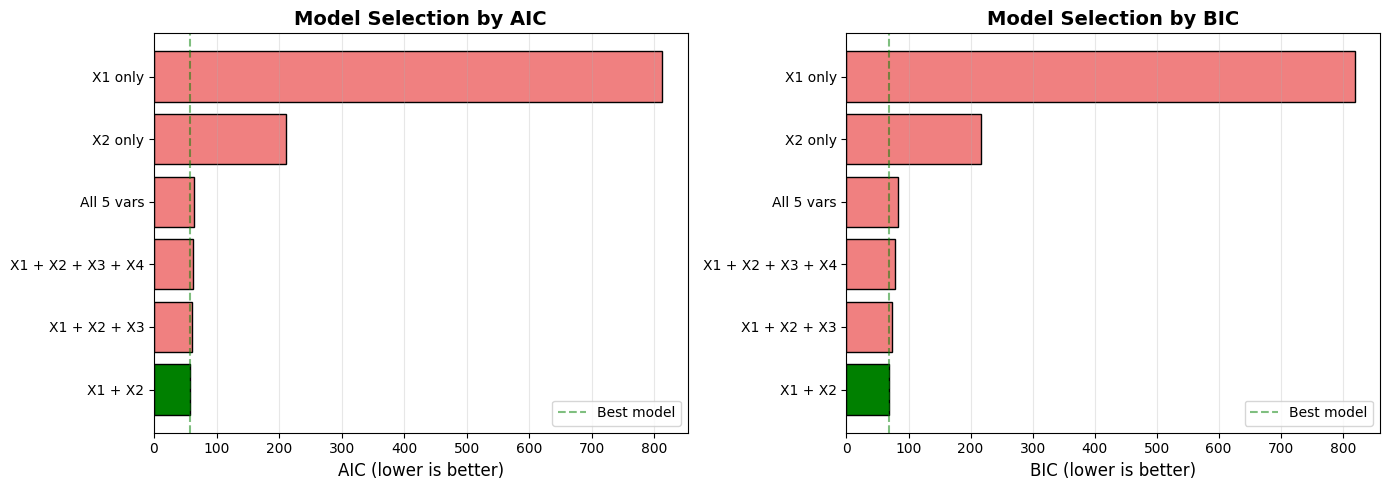


Green bar indicates the true model (X1 + X2)
Both criteria correctly identify the true model


In [3]:
# Visualize AIC and BIC values
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AIC comparison
ax1 = axes[0]
colors = ['green' if 'X1 + X2' == name and 'X3' not in name and 'X4' not in name and 'X5' not in name 
          else 'lightcoral' for name in df_models.index]
bars1 = ax1.barh(range(len(df_models)), df_models['AIC'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(df_models)))
ax1.set_yticklabels(df_models.index)
ax1.set_xlabel('AIC (lower is better)', fontsize=12)
ax1.set_title('Model Selection by AIC', fontsize=14, fontweight='bold')
ax1.axvline(df_models['AIC'].min(), color='green', linestyle='--', alpha=0.5, label='Best model')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: BIC comparison
ax2 = axes[1]
df_bic_sorted = df_models.sort_values('BIC')
colors = ['green' if 'X1 + X2' == name and 'X3' not in name and 'X4' not in name and 'X5' not in name 
          else 'lightcoral' for name in df_bic_sorted.index]
bars2 = ax2.barh(range(len(df_bic_sorted)), df_bic_sorted['BIC'], color=colors, edgecolor='black')
ax2.set_yticks(range(len(df_bic_sorted)))
ax2.set_yticklabels(df_bic_sorted.index)
ax2.set_xlabel('BIC (lower is better)', fontsize=12)
ax2.set_title('Model Selection by BIC', fontsize=14, fontweight='bold')
ax2.axvline(df_bic_sorted['BIC'].min(), color='green', linestyle='--', alpha=0.5, label='Best model')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nGreen bar indicates the true model (X1 + X2)")
print("Both criteria correctly identify the true model")